In [ ]:
# 🛠️ Install required packages
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet

In [1]:
# 📚 Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [2]:
# 📥 1. Load Dataset
# from google.colab import files
# uploaded = files.upload()
df = pd.read_csv('water_potability.csv')

Dataset shape: (3276, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB
None

Missing values per feature:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0

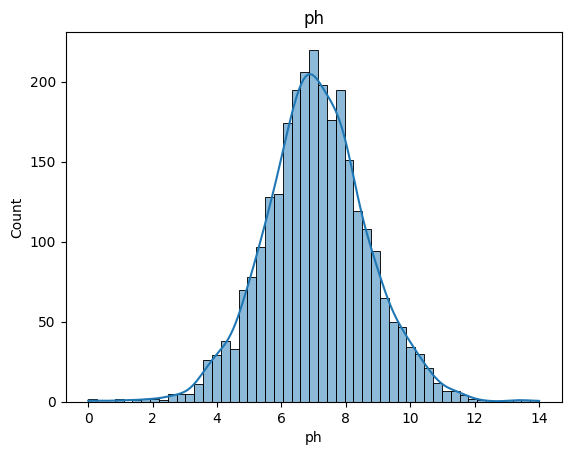

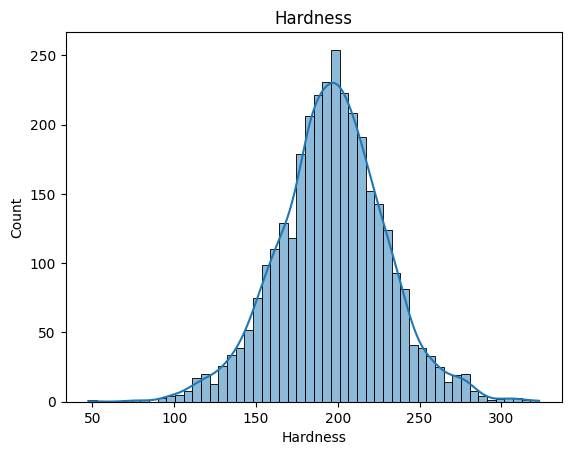

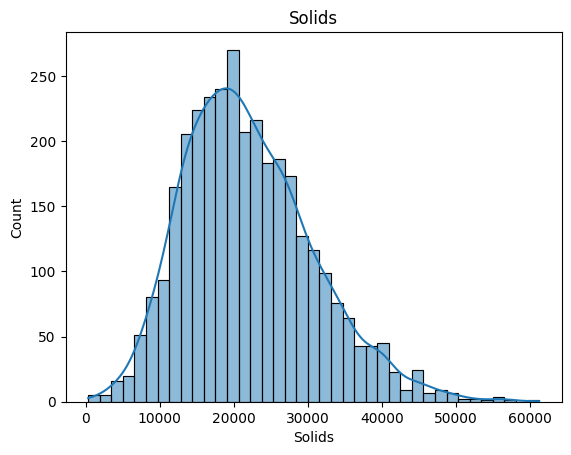

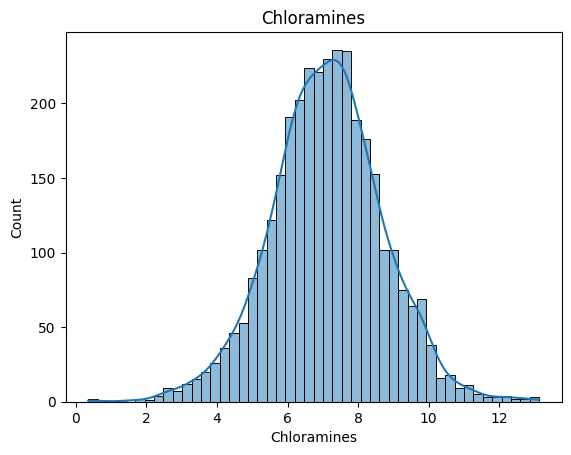

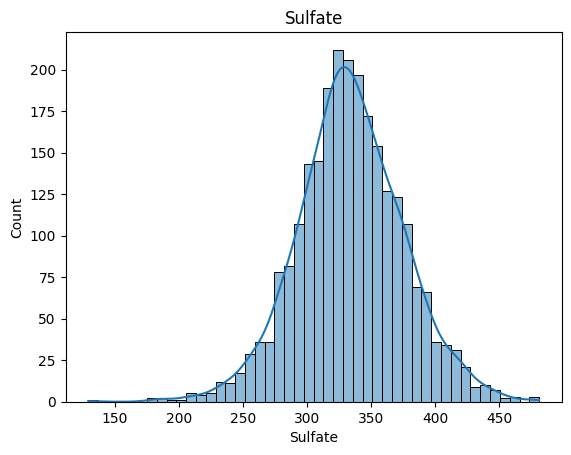

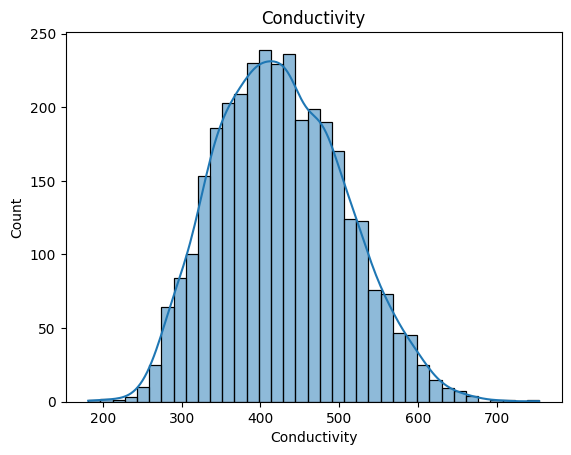

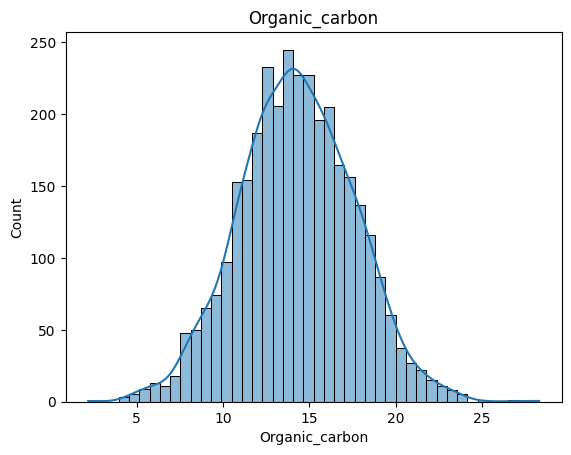

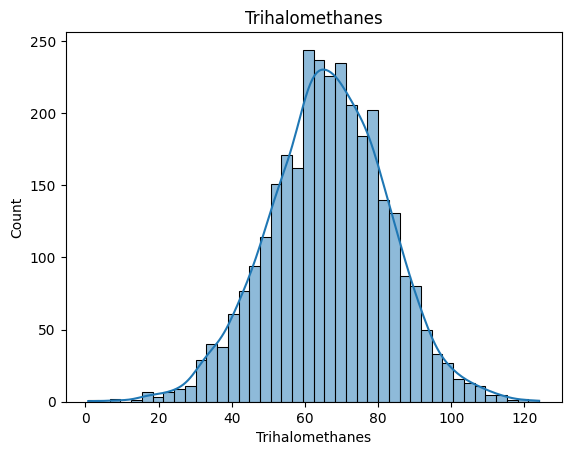

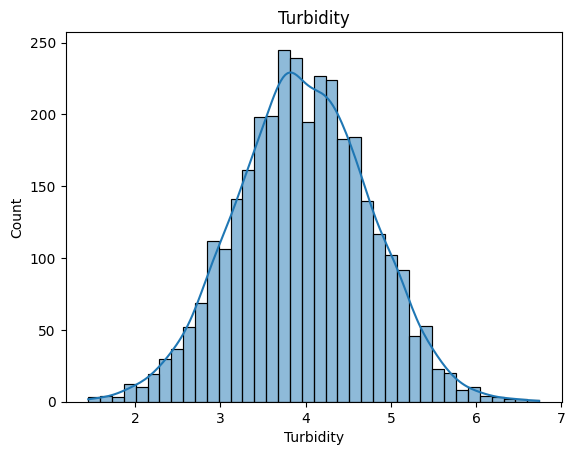

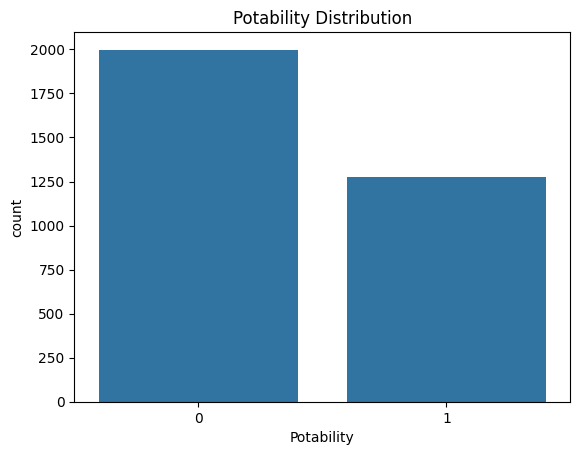

In [3]:
# 🧠 2. Exploratory Data Analysis (EDA)
print(f"Dataset shape: {df.shape}")
print(df.info())
print("\nMissing values per feature:")
print(df.isnull().sum())
numeric_cols = df.columns.drop('Potability')
for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col].dropna(), kde=True).set_title(col)
plt.figure()
sns.countplot(x='Potability', data=df).set_title('Potability Distribution')
plt.show()

In [4]:
# 🧹 3. Data Preparation
y = df['Potability']
X = df.drop('Potability', axis=1)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

In [5]:
# 🧪 4. Feature Selection
selector = SelectKBest(score_func=f_classif, k=5)
X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel = selector.transform(X_test)
selected_features = X.columns[selector.get_support()]
print("Selected features:", list(selected_features))

Selected features: ['Solids', 'Chloramines', 'Conductivity', 'Organic_carbon', 'Trihalomethanes']



KNN Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.75      0.67       600
           1       0.40      0.26      0.32       383

    accuracy                           0.56       983
   macro avg       0.51      0.50      0.49       983
weighted avg       0.53      0.56      0.53       983



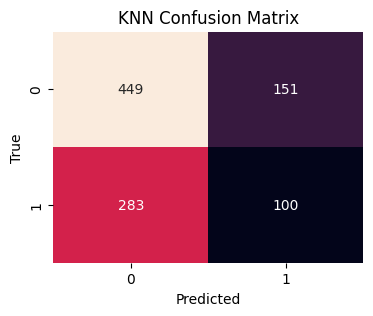


Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.93      0.74       600
           1       0.39      0.07      0.12       383

    accuracy                           0.60       983
   macro avg       0.50      0.50      0.43       983
weighted avg       0.53      0.60      0.50       983



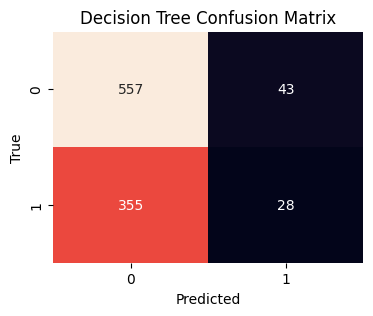


SVC Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.96      0.75       600
           1       0.52      0.07      0.12       383

    accuracy                           0.61       983
   macro avg       0.57      0.51      0.43       983
weighted avg       0.58      0.61      0.50       983



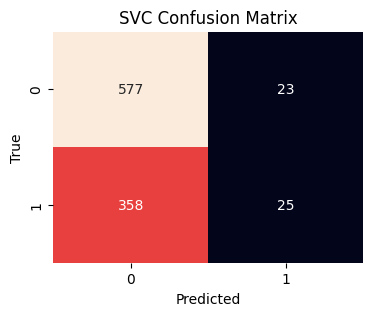


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.90      0.77       600
           1       0.66      0.29      0.41       383

    accuracy                           0.67       983
   macro avg       0.66      0.60      0.59       983
weighted avg       0.66      0.67      0.63       983



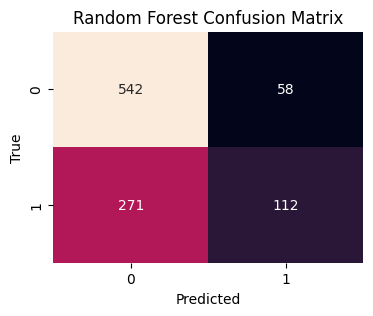

In [6]:
# 🤖 5. Model Experiments
results = []
def eval_grid(name, pipeline, params, Xtr, Xte):
    gs = GridSearchCV(pipeline, params, cv=5)
    gs.fit(Xtr, y_train)
    preds = gs.predict(Xte)
    metrics = {
        'Model': name,
        'Best Params': gs.best_params_,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds)
    }
    results.append(metrics)
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, preds))
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cbar=False)
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
exp_configs = [
    ('KNN', Pipeline([('clf', KNeighborsClassifier())]), {'clf__n_neighbors': [3,5,7], 'clf__weights': ['uniform','distance']}, X_train_sel, X_test_sel),
    ('Decision Tree', Pipeline([('clf', DecisionTreeClassifier(random_state=42))]), {'clf__max_depth': [None,5,10], 'clf__min_samples_leaf': [1,2,5]}, X_train_sel, X_test_sel),
    ('SVC', Pipeline([('clf', SVC(random_state=42))]), {'clf__C': [0.1,1,10], 'clf__kernel': ['linear','rbf']}, X_train_sel, X_test_sel),
    ('Random Forest', Pipeline([('clf', RandomForestClassifier(random_state=42))]), {'clf__n_estimators': [100,200], 'clf__max_depth': [None,10]}, X_train, X_test)
]
for name, pipe, params, Xtr, Xte in exp_configs:
    eval_grid(name, pipe, params, Xtr, Xte)


Comparison of Model Performance:
           Model                                        Best Params  Accuracy  \
0            KNN  {'clf__n_neighbors': 7, 'clf__weights': 'unifo...  0.558494   
1  Decision Tree  {'clf__max_depth': 5, 'clf__min_samples_leaf': 2}  0.595117   
2            SVC                {'clf__C': 1, 'clf__kernel': 'rbf'}  0.612411   
3  Random Forest  {'clf__max_depth': None, 'clf__n_estimators': ...  0.665310   

   Precision    Recall        F1  
0   0.398406  0.261097  0.315457  
1   0.394366  0.073107  0.123348  
2   0.520833  0.065274  0.116009  
3   0.658824  0.292428  0.405063  


<Figure size 800x500 with 0 Axes>

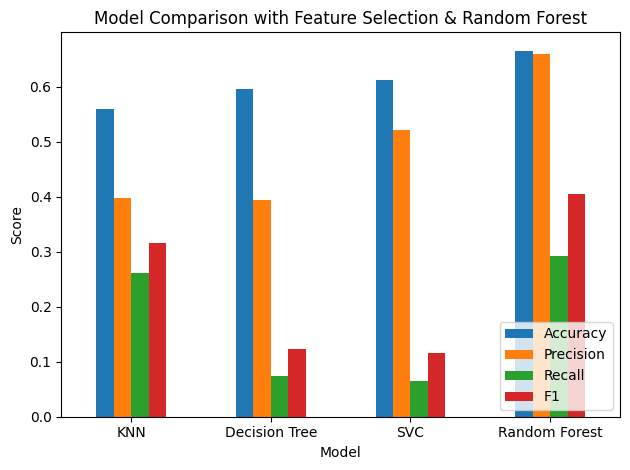

In [7]:
# 📈 6. Results Comparison
res_df = pd.DataFrame(results)
print("\nComparison of Model Performance:")
print(res_df[['Model','Best Params','Accuracy','Precision','Recall','F1']])
plt.figure(figsize=(8,5))
res_df.set_index('Model')[['Accuracy','Precision','Recall','F1']].plot(kind='bar')
plt.title('Model Comparison with Feature Selection & Random Forest')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [8]:
# 💾 7. Save to CSV
res_df.to_csv('model_comparison_results.csv', index=False)
print("Saved comparison table to 'model_comparison_results.csv'")

Saved comparison table to 'model_comparison_results.csv'
